In [ ]:
# 08 - Error Analysis

## Objective

#Analyze the performance of the final Logistic Regression model by:

#- Evaluating the confusion matrix
#- Generating a classification report
#- Identifying misclassified reviews
#- Understanding common sources of prediction errors

#This analysis provides insights into the strengths and limitations of the proposed model.

In [1]:
import pickle
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/clean_movie_comments.csv")

print(df.shape)

df.head()

(4775, 5)


,Video ID,Cleaned Comment,Movie Rating,Volgur Comment,Movie Category
0,JZMT84XFbSk,this movie is excellent bro..niku anil ravipud...,Excellent,No,Not Able to Judge
1,JZMT84XFbSk,"Its full family movie ra , stop seeing crime a...",Neutral,No,Not Able to Judge
2,JZMT84XFbSk,Exactly second half lo comedy scenes were too ...,Very Good,No,Not Able to Judge
3,JZMT84XFbSk,Super movie.go watch it,Very Good,No,Not Able to Judge
4,JZMT84XFbSk,First half avg. Emotional sequence in Second h...,Neutral,No,Not Able to Judge


In [3]:
with open("../models/final_pipeline.pkl", "rb") as f:
    pipeline = pickle.load(f)

print("Pipeline Loaded Successfully!")

Pipeline Loaded Successfully!


In [4]:
from sklearn.model_selection import train_test_split

X = df["Cleaned Comment"]
y = df["Movie Rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
y_pred = pipeline.predict(X_test)

In [6]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Excellent       0.96      0.84      0.90       203
     Neutral       0.81      0.70      0.75       142
    Not Good       0.80      0.29      0.43        55
        Poor       0.80      0.94      0.87       235
   Very Good       0.81      0.91      0.86       320

    accuracy                           0.84       955
   macro avg       0.84      0.74      0.76       955
weighted avg       0.84      0.84      0.83       955



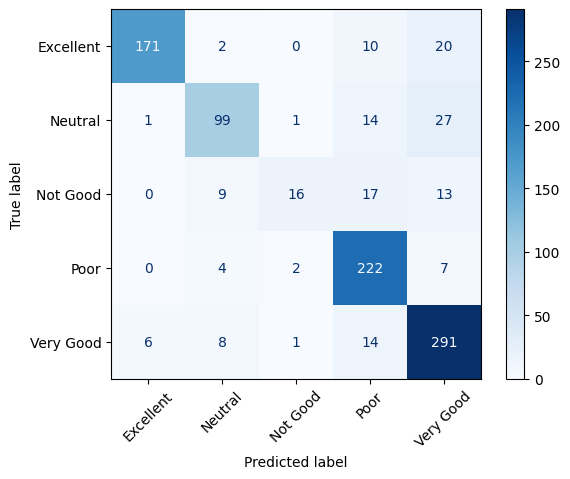

In [7]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=pipeline.classes_
)

disp.plot(cmap="Blues")

plt.xticks(rotation=45)

plt.show()

In [8]:
results = pd.DataFrame({
    "Comment": X_test.values,
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head()

,Comment,Actual,Predicted
0,2 out of 5,Poor,Poor
1,Finally tuck removed 🤣,Poor,Poor
2,Movie ok but comedy mess,Not Good,Not Good
3,"Rod u, Rodunnara, Rod u Square 😂😭🤣",Poor,Poor
4,Blockbuster,Excellent,Excellent


In [9]:
errors = results[
    results["Actual"] != results["Predicted"]
]

print("Total Misclassified Reviews:", len(errors))

Total Misclassified Reviews: 156


In [10]:
errors.head(20)

,Comment,Actual,Predicted
7,Nuvu mari bad ga cheptunnav anipistundi bro. I...,Neutral,Very Good
9,Nenu chusanu bro average,Not Good,Neutral
10,Nice 👌,Very Good,Neutral
14,Super wonderful Anna,Excellent,Very Good
24,Bagundi bro movie,Neutral,Very Good
31,BOSS come back movie,Neutral,Poor
32,Miru yentha cheppina 500 crores anil finger mi...,Neutral,Poor
34,Movie chala bhagundi meru em chepina janalu ch...,Excellent,Very Good
39,"Headache ochesindhi lagg thoni, climax kuda en...",Not Good,Poor
43,I love mouli bro but nu intha support ga chepp...,Not Good,Very Good


In [12]:
import os

os.makedirs("../results", exist_ok=True)

errors.to_csv(
    "../results/misclassified_reviews.csv",
    index=False
)

print("Saved Successfully!")

Saved Successfully!


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Excellent       0.96      0.84      0.90       203
     Neutral       0.81      0.70      0.75       142
    Not Good       0.80      0.29      0.43        55
        Poor       0.80      0.94      0.87       235
   Very Good       0.81      0.91      0.86       320

    accuracy                           0.84       955
   macro avg       0.84      0.74      0.76       955
weighted avg       0.84      0.84      0.83       955



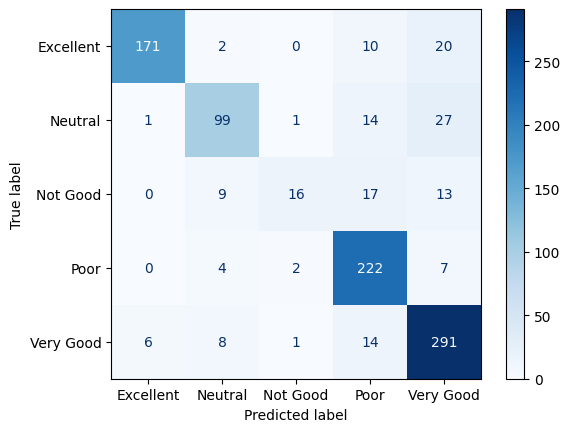

In [14]:
disp.plot(cmap="Blues")

In [15]:
errors.head(10)

,Comment,Actual,Predicted
7,Nuvu mari bad ga cheptunnav anipistundi bro. I...,Neutral,Very Good
9,Nenu chusanu bro average,Not Good,Neutral
10,Nice 👌,Very Good,Neutral
14,Super wonderful Anna,Excellent,Very Good
24,Bagundi bro movie,Neutral,Very Good
31,BOSS come back movie,Neutral,Poor
32,Miru yentha cheppina 500 crores anil finger mi...,Neutral,Poor
34,Movie chala bhagundi meru em chepina janalu ch...,Excellent,Very Good
39,"Headache ochesindhi lagg thoni, climax kuda en...",Not Good,Poor
43,I love mouli bro but nu intha support ga chepp...,Not Good,Very Good


<Figure size 800x600 with 0 Axes>

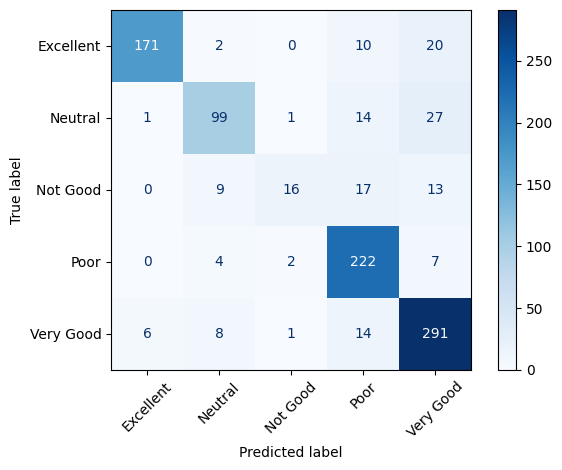

In [16]:
plt.figure(figsize=(8,6))

disp.plot(cmap="Blues", values_format="d")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../results/confusion_matrix.png", dpi=300)
plt.show()

In [17]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

pd.DataFrame(report).transpose().to_csv(
    "../results/classification_report.csv"
)